# Comprensión del Negocio

El sistema MediPac tiene como objetivo mejorar la gestión de recetas médicas priorizando la atención en función de la urgencia. Esto reducirá los tiempos de espera y optimizará el flujo de trabajo en la farmacia.

El objetivo es clasificar las recetas en 3 niveles de prioridad:
- **A**: Atención urgente
- **B**: Atención media
- **C**: Atención que puede esperar


# Entendimiento de los datos


In [ ]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score


In [ ]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    name=fn
df = pd.read_csv(name, sep=";")

Saving proyecto.csv to proyecto.csv


In [ ]:
df.head(19)

,ID_Receta,Condicion_Medica,Edad_Paciente,Sexo,Frecuencia_Visitas,Rango_Hora_Solicitud,Prioridad,Historial_Medico
0,REC-001,hepatitis,62,Femenino,10,noche,B,historial de alergias
1,REC-002,enfermedad cardíaca,44,Masculino,6,noche,C,sin antecedentes
2,REC-003,artritis,66,Masculino,1,noche,B,sin antecedentes
3,REC-004,alzheimer,57,Masculino,10,tarde,C,historial de alergias
4,REC-005,depresión severa,22,Femenino,10,tarde,C,historial de hipertensión
5,REC-006,migraña,45,Masculino,4,noche,B,sin antecedentes
6,REC-007,ansiedad generalizada,13,Femenino,1,noche,B,sin historial significativo
7,REC-008,fibromialgia,86,Femenino,5,mañana,B,historial de alergias
8,REC-009,hepatitis,42,Femenino,6,noche,A,historial oncológico
9,REC-010,esclerosis múltiple,17,Femenino,11,tarde,A,historial de alergias


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID_Receta             300 non-null    object
 1   Condicion_Medica      300 non-null    object
 2   Edad_Paciente         300 non-null    int64 
 3   Sexo                  300 non-null    object
 4   Frecuencia_Visitas    300 non-null    int64 
 5   Rango_Hora_Solicitud  300 non-null    object
 6   Prioridad             300 non-null    object
 7   Historial_Medico      300 non-null    object
dtypes: int64(2), object(6)
memory usage: 18.9+ KB


In [ ]:
#creación variables dummy
df.Condicion_Medica.unique()

array(['hepatitis', 'enfermedad cardíaca', 'artritis', 'alzheimer',
       'depresión severa', 'migraña', 'ansiedad generalizada',
       'fibromialgia', 'esclerosis múltiple', 'anemia severa',
       'colesterol alto', 'obesidad severa', 'enfermedad renal crónica',
       'alergia severa', 'insuficiencia respiratoria', 'diabetes con',
       'epilepsia', 'osteoporosis', 'cirrosis', 'hipotiroidismo',
       'cáncer', 'parkinson', 'asma con', 'lupus', 'hipertensión con'],
      dtype=object)

# PREPARACION DE DATOS

In [ ]:
df.drop(columns=(['Rango_Hora_Solicitud','Frecuencia_Visitas','Historial_Medico']), inplace=True)

In [ ]:
enfermedades_dummies = {
    'diabetes con': 45,
    'hipertensión con': 1,
    'asma con': 2,
    'enfermedad cardíaca': 3,
    'alergia severa': 4,
    'colesterol alto': 5,
    'artritis': 6,
    'enfermedad renal crónica': 7,
    'cáncer': 8,
    'migraña': 9,
    'depresión severa': 10,
    'ansiedad generalizada': 11,
    'hepatitis': 12,
    'alzheimer': 13,
    'fibromialgia': 14,
    'esclerosis múltiple': 15,
    'anemia severa': 16,
    'obesidad severa': 17,
    'insuficiencia respiratoria': 18,
    'epilepsia': 19,
    'osteoporosis': 20,
    'cirrosis': 21,
    'hipotiroidismo': 22,
    'parkinson': 23,
    'lupus': 24,
    'hipertension': 25,
    'diabetes' : 26
}





In [ ]:

# Crear el diccionario de severidad según la condición médica
severidad_dict = {
    'diabetes con': 2,  # Severa
    'hipertensión con': 1,  # Moderada
    'asma con': 1,  # Moderada
    'enfermedad cardíaca': 2,  # Severa
    'alergia severa': 0,  # Leve
    'colesterol alto': 0,  # Leve
    'artritis': 1,  # Moderada
    'enfermedad renal crónica': 2,  # Severa
    'cáncer': 2,  # Severa
    'migraña': 0,  # Leve
    'depresión severa': 1,  # Moderada
    'ansiedad generalizada': 0,  # Leve
    'hepatitis': 2,  # Severa
    'alzheimer': 2,  # Severa
    'fibromialgia': 1,  # Moderada
    'esclerosis múltiple': 2,  # Severa
    'anemia severa': 2,  # Severa
    'obesidad severa': 1,  # Moderada
    'insuficiencia respiratoria': 2,  # Severa
    'epilepsia': 1,  # Moderada
    'osteoporosis': 1,  # Moderada
    'cirrosis': 2,  # Severa
    'hipotiroidismo': 1,  # Moderada
    'parkinson': 2,  # Severa
    'lupus': 2,  # Severa
    'hipertension': 2,
    'diabetes' : 1
}

# Asignar severidad a la columna 'Severidad' según 'Condicion_Medica'
df['Severidad'] = df['Condicion_Medica'].map(severidad_dict).fillna(0)  # Asignar "0" si no está en el diccionario

# Mostrar el resultado
print(df)

    ID_Receta     Condicion_Medica  Edad_Paciente       Sexo Prioridad  \
0     REC-001            hepatitis             62   Femenino         B   
1     REC-002  enfermedad cardíaca             44  Masculino         C   
2     REC-003             artritis             66  Masculino         B   
3     REC-004            alzheimer             57  Masculino         C   
4     REC-005     depresión severa             22   Femenino         C   
..        ...                  ...            ...        ...       ...   
295   REC-296        anemia severa             25  Masculino         B   
296   REC-297              migraña             60  Masculino         B   
297   REC-298     depresión severa             25  Masculino         A   
298   REC-299       hipotiroidismo             10  Masculino         C   
299   REC-300       hipotiroidismo             65  Masculino         A   

     Severidad  
0            2  
1            2  
2            1  
3            2  
4            1  
..       

In [ ]:
df.head(23)

,ID_Receta,Condicion_Medica,Edad_Paciente,Sexo,Prioridad,Severidad
0,REC-001,hepatitis,62,Femenino,B,2
1,REC-002,enfermedad cardíaca,44,Masculino,C,2
2,REC-003,artritis,66,Masculino,B,1
3,REC-004,alzheimer,57,Masculino,C,2
4,REC-005,depresión severa,22,Femenino,C,1
5,REC-006,migraña,45,Masculino,B,0
6,REC-007,ansiedad generalizada,13,Femenino,B,0
7,REC-008,fibromialgia,86,Femenino,B,1
8,REC-009,hepatitis,42,Femenino,A,2
9,REC-010,esclerosis múltiple,17,Femenino,A,2


In [ ]:
# Cambiar los valores de la columna Prioridad
df['Prioridad'] = df['Prioridad'].replace({'A': 0, 'B': 1, 'C': 2})

# Verificar el cambio
print(df[['ID_Receta', 'Prioridad']])


    ID_Receta  Prioridad
0     REC-001          1
1     REC-002          2
2     REC-003          1
3     REC-004          2
4     REC-005          2
..        ...        ...
295   REC-296          1
296   REC-297          1
297   REC-298          0
298   REC-299          2
299   REC-300          0

[300 rows x 2 columns]


<ipython-input-11-db1be2eaa6e1>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Prioridad'] = df['Prioridad'].replace({'A': 0, 'B': 1, 'C': 2})


In [ ]:

df['Condicion_Medica'] = df['Condicion_Medica'].replace(enfermedades_dummies)

print(df.head())


  ID_Receta  Condicion_Medica  Edad_Paciente       Sexo  Prioridad  Severidad
0   REC-001                12             62   Femenino          1          2
1   REC-002                 3             44  Masculino          2          2
2   REC-003                 6             66  Masculino          1          1
3   REC-004                13             57  Masculino          2          2
4   REC-005                10             22   Femenino          2          1


<ipython-input-12-9c4ad5feb869>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Condicion_Medica'] = df['Condicion_Medica'].replace(enfermedades_dummies)


In [ ]:
df.head(20)

,ID_Receta,Condicion_Medica,Edad_Paciente,Sexo,Prioridad,Severidad
0,REC-001,12,62,Femenino,1,2
1,REC-002,3,44,Masculino,2,2
2,REC-003,6,66,Masculino,1,1
3,REC-004,13,57,Masculino,2,2
4,REC-005,10,22,Femenino,2,1
5,REC-006,9,45,Masculino,1,0
6,REC-007,11,13,Femenino,1,0
7,REC-008,14,86,Femenino,1,1
8,REC-009,12,42,Femenino,0,2
9,REC-010,15,17,Femenino,0,2


In [ ]:
df.Sexo.unique()

array(['Femenino', 'Masculino'], dtype=object)

In [ ]:
df.Sexo.replace({"Masculino":1,"Femenino":2}, inplace=True)

<ipython-input-15-b456cf99548a>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Sexo.replace({"Masculino":1,"Femenino":2}, inplace=True)
<ipython-input-15-b456cf99548a>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.Sexo.replace({"Masculino":1,"Femenino":2}, inplace=True)


In [ ]:
df.head()

,ID_Receta,Condicion_Medica,Edad_Paciente,Sexo,Prioridad,Severidad
0,REC-001,12,62,2,1,2
1,REC-002,3,44,1,2,2
2,REC-003,6,66,1,1,1
3,REC-004,13,57,1,2,2
4,REC-005,10,22,2,2,1


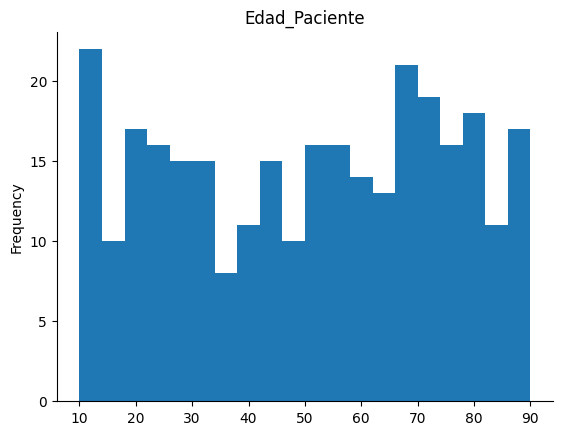

In [ ]:

from matplotlib import pyplot as plt
df['Edad_Paciente'].plot(kind='hist', bins=20, title='Edad_Paciente')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# Preparación de los Datos

# Crear una columna de rango de edad (ejemplo)
df['Rango_Edad'] = pd.cut(df['Edad_Paciente'], bins=[0, 18, 35, 50, 65, 100], labels=['Niño', 'Joven', 'Adulto', 'Maduro', 'Senior'])





In [ ]:
import pandas as pd
import numpy as np

# Definir los rangos de edad
bins = [0, 18, 35, 50, 65, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '66+']

# Crear una nueva columna 'Rango_Edad' con los rangos de edad
df['Rango_Edad'] = pd.cut(df['Edad_Paciente'], bins=bins, labels=labels, right=True)

# Mostrar el DataFrame con los rangos de edad
print(df[['Edad_Paciente', 'Rango_Edad']])


     Edad_Paciente Rango_Edad
0               62      51-65
1               44      36-50
2               66        66+
3               57      51-65
4               22      19-35
..             ...        ...
295             25      19-35
296             60      51-65
297             25      19-35
298             10       0-18
299             65      51-65

[300 rows x 2 columns]


In [ ]:
df.head(10)

,ID_Receta,Condicion_Medica,Edad_Paciente,Sexo,Prioridad,Severidad,Rango_Edad
0,REC-001,12,62,2,1,2,51-65
1,REC-002,3,44,1,2,2,36-50
2,REC-003,6,66,1,1,1,66+
3,REC-004,13,57,1,2,2,51-65
4,REC-005,10,22,2,2,1,19-35
5,REC-006,9,45,1,1,0,36-50
6,REC-007,11,13,2,1,0,0-18
7,REC-008,14,86,2,1,1,66+
8,REC-009,12,42,2,0,2,36-50
9,REC-010,15,17,2,0,2,0-18


In [ ]:
X = df.drop(columns=['ID_Receta', 'Prioridad'])
y = df['Prioridad']

In [ ]:

# Definir los rangos de edad y asignarles un valor numérico
bins = [0, 18, 35, 50, 65, 100]
labels = [1, 2, 3, 4, 5]  # Asignamos números a los rangos

# Crear una nueva columna 'Rango_Edad' con los valores numéricos
df['Rango_Edad'] = pd.cut(df['Edad_Paciente'], bins=bins, labels=labels, right=True)

print("DataFrame con Rango de Edad numérico:")
print(df[['Edad_Paciente', 'Rango_Edad']])

X = df[['Edad_Paciente', 'Rango_Edad']]  # Incluye la edad y el rango numérico

# Mostrar las columnas escaladas
print("\nDataFrame escalado:")
print(X_scaled)


DataFrame con Rango de Edad numérico:
     Edad_Paciente Rango_Edad
0               62          4
1               44          3
2               66          5
3               57          4
4               22          2
..             ...        ...
295             25          2
296             60          4
297             25          2
298             10          1
299             65          4

[300 rows x 2 columns]

DataFrame escalado:


NameError: name 'X_scaled' is not defined

In [ ]:
df.head(10)

# Modelamiento

##REGRESION LOGISTICA

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("Reporte de Clasificación - Regresión Logística")
print(classification_report(y_test, y_pred_logreg))


##KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("Reporte de Clasificación - KNN")
print(classification_report(y_test, y_pred_knn))
print("R squared of the knn on training set: {:.2%}".format(knn.score(X_train_scaled, y_train)))
print("R squared of the knn on test set: {:.2%}".format(knn.score(X_test_scaled, y_test)))


In [ ]:
df.head(10)

,ID_Receta,Condicion_Medica,Edad_Paciente,Sexo,Prioridad,Severidad,Rango_Edad
0,REC-001,12,62,2,1,2,4
1,REC-002,3,44,1,2,2,3
2,REC-003,6,66,1,1,1,5
3,REC-004,13,57,1,2,2,4
4,REC-005,10,22,2,2,1,2
5,REC-006,9,45,1,1,0,3
6,REC-007,11,13,2,1,0,1
7,REC-008,14,86,2,1,1,5
8,REC-009,12,42,2,0,2,3
9,REC-010,15,17,2,0,2,1


##KMEANS


In [ ]:
# Definir X (características)
X = df[['Condicion_Medica', 'Edad_Paciente', 'Sexo']]

X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)

# Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_scaled = scaler.fit_transform(X)

# Aplicar KMeans con 3 clusters a los datos escalados
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Mapear clústeres a etiquetas de prioridad
cluster_to_prioridad = {0: 'A', 1: 'B', 2: 'C'}  # Revisión manual sugerida según grupos
df['Prioridad_KMeans'] = df['Cluster'].map(cluster_to_prioridad)

# Mostrar resultados
print(df[['ID_Receta', 'Cluster', 'Prioridad_KMeans']])


    ID_Receta  Cluster Prioridad_KMeans
0     REC-001        0                A
1     REC-002        2                C
2     REC-003        2                C
3     REC-004        2                C
4     REC-005        1                B
..        ...      ...              ...
295   REC-296        2                C
296   REC-297        2                C
297   REC-298        2                C
298   REC-299        2                C
299   REC-300        2                C

[300 rows x 3 columns]


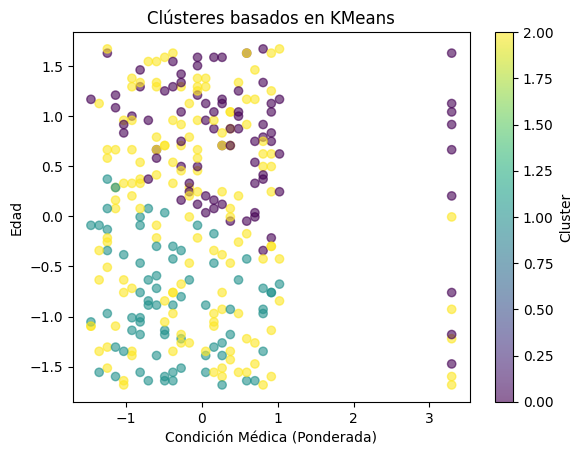

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Condición Médica (Ponderada)')
plt.ylabel('Edad')
plt.title('Clústeres basados en KMeans')
plt.colorbar(label='Cluster')
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"Índice de Silueta: {silhouette_avg:.3f}")


Índice de Silueta: 0.353


In [ ]:
df.head(10)

,ID_Receta,Condicion_Medica,Edad_Paciente,Sexo,Prioridad,Severidad,Rango_Edad,Cluster,Prioridad_KMeans
0,REC-001,12,62,2,1,2,4,0,A
1,REC-002,3,44,1,2,2,3,2,C
2,REC-003,6,66,1,1,1,5,2,C
3,REC-004,13,57,1,2,2,4,2,C
4,REC-005,10,22,2,2,1,2,1,B
5,REC-006,9,45,1,1,0,3,2,C
6,REC-007,11,13,2,1,0,1,1,B
7,REC-008,14,86,2,1,1,5,0,A
8,REC-009,12,42,2,0,2,3,1,B
9,REC-010,15,17,2,0,2,1,1,B


In [ ]:
with open('kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [ ]:
import numpy as np
import pickle

with open('kmeans.pkl', 'rb') as file:
    modelo = pickle.load(file)

with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

# Datos de prueba para un paciente
paciente = {
    "condicion_medica": 13,
    "edad": 80,
    "sexo": 2  # 1 = Masculino, 2 = Femenino
}

data_input = np.array([[paciente["condicion_medica"],
                        paciente["edad"],
                        paciente["sexo"]]])

data_scaled = scaler.transform(data_input)

# Predecir el cluster
prediccion_cluster = modelo.predict(data_scaled)

cluster_to_prioridad = {0: 'A', 1: 'B', 2: 'C'}
prioridad = cluster_to_prioridad[prediccion_cluster[0]]

# Mostrar la prioridad
print(f"El paciente pertenece a la prioridad: {prioridad}")


El paciente pertenece a la prioridad: A


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
